# Aggregated Interface Interaction Analysis in Dimers

Compare protein-protein interfaces across all deposited structures of one **dimeric** complex. Interfaces are clustered by interaction-pair similarity, then mutations, modifications and ligands are overlaid. Each cluster is a candidate **interface interaction state**, a recurring pattern of residue-residue contacts that distinguishes a subset of structures.

**Dimers only, both components mapped to UniProt.** Where an instance has more than two components, the correspondence between chains cannot be determined, so its interfaces are not comparable across structures. Complexes with more than two components are rejected, and assembly instances carrying an additional bound macromolecule are excluded in Phase 1.

Caveats are listed as guidance at the phase they apply to.

Copyright 2026 EMBL - European Bioinformatics Institute. Licensed under the Apache License, Version 2.0; see the licence cell at the end of this notebook or the `LICENSE` file.

## Configuration

All parameters are set below; field documentation is in the `Config` docstring. `identifier` takes a PDB entry id such as `"11gl"` or a complex id such as `"PDB-CPX-172174"`. Either way the analysis covers every deposited structure of the resolved complex.

**Finding a complex id for one entry.** Open the entry page on the PDBe website and go to the Complexes tab, where the complex id is listed. Each unique assembly composition has its own complex id.

**Finding complex ids in bulk.** The PDBe-KB complexes FTP area, https://ftp.ebi.ac.uk/pub/databases/pdbe-kb/complexes/, carries the full set. In `assemblies_data.csv`, `PDB_COMPLEX_ID` holds the identifier, `ASSEMBLY_STRING` the composition it stands for, and `ASSEMBLIES` the `pdb_id_assembly` values belonging to it.

In [1]:
from pdbe_interfaces import (
    Config, setup_logging, api, representation, similarity,
    annotations, outputs, plots, explorer, visualize,
)

cfg = Config(
    # PDB entry id or PDB complex id. Dimers only. Prefer the entry id: the
    # complex id is resolved from PDBe and can be reassigned between PDBe-KB
    # Complexes releases, so it is a data value rather than a permanent name.
    # "11gl" is the STING homodimer (Complex Portal CPX-2128), a small all-X-ray
    # dataset. "1spq" (triosephosphate isomerase) is a homodimer with an
    # invariant interface, and "6m0j" (Spike RBD with ACE2) a much larger
    # heterodimer. Interface and entry counts grow as structures are deposited,
    # so the run below reports whatever PDBe currently returns.
    identifier="11gl",

    # Mutation types retained. Add "Conflict" to include natural sequence variants.
    mutation_type_filter=("Engineered mutation",),

    # Components excluded from the ligand analysis: counter-ions, buffers,
    # cryoprotectants, reducing agents. Remove an id to retain it, for example a
    # catalytic metal.
    ligand_blocklist=frozenset({
        "CL", "NA", "MG", "ZN", "CA", "K",
        "SO4", "GOL", "HOH", "EDO", "PEG", "MPD", "ACT",
        "SGM", "DTT", "BME", "TRS",
    }),
    drop_carbohydrate_polymers=False,

    # Resolution ceiling in Angstroms; None disables the filter.
    max_resolution=None,

    # Restrict to the first N PDB entries alphabetically, for a quick check.
    # A subset biases the clustering and every conservation fraction.
    max_entries=None,

    # Threads for the per-entry and per-ligand retrieval in Phase 1.
    max_workers=8,

    # Fraction of interfaces required for a residue or contact to count as conserved.
    conservation_threshold=0.8,

    # Dendrogram cut height in 1 - Jaccard units. Sets the number of states
    # reported, so inspect the dendrogram in Phase 3 before accepting it.
    cluster_distance_cut=0.6,

    log_level="INFO",
    output_dir="interface_frequencies",
)

setup_logging(cfg.log_level)
cfg.describe()

,value
setting,
identifier,11gl
mutation_type_filter,Engineered mutation
ligand_blocklist,"ACT, BME, CA, CL, DTT, EDO, GOL, HOH, K, MG, M..."
drop_carbohydrate_polymers,False
max_resolution,None
max_entries,None
max_workers,8
conservation_threshold,0.8
cluster_distance_cut,0.6


## Phase 1. Data retrieval

Resolve the identifier, check the complex is a dimer, apply the assembly filters, retrieve interfaces, mutations, modifications and ligands.

**Guidance**
- Read the exclusion list below before continuing. Instances carrying a macromolecule beyond the two UniProt-mapped components are excluded, since chain correspondence cannot be determined for them.
- Treat every frequency in this notebook as describing the structures deposited for this complex, not binding modes in solution.
- For complexes with more than two components, stop here. This notebook cannot analyse them.

In [2]:
complex_id, details = api.resolve_complex_id(cfg.identifier, require_dimer=True)
partner_map = outputs.build_partner_map(details)
assembly_metadata = outputs.extract_assembly_metadata(details)
print(outputs.describe_complex(complex_id, details, partner_map,
                               assembly_metadata, identifier=cfg.identifier))

08:18:58 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/complex/details/11gl?id_type=pdb_id


08:18:58 [INFO] pdbe_interfaces.api: Resolved PDB entry 11gl to complex PDB-CPX-172174


08:18:58 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/complex/details/PDB-CPX-172174?id_type=pdb_complex_id


Resolved 11gl to PDB-CPX-172174
Complex: Sting complex (PDB-CPX-172174)
Oligomeric state: Homodimer
Partners: {('Q3TBT3', 1): 'Sting1 (role 1)', ('Q3TBT3', 2): 'Sting1 (role 2)'}
Assembly metadata for 14 (pdb_id, assembly_id) pairs


In [3]:
selection = representation.select_interfaces(
    api.fetch_interface_interactions(complex_id), details,
    max_resolution=cfg.max_resolution,
    max_entries=cfg.max_entries,
)
interface_response, pdb_ids = selection.interfaces, selection.pdb_ids
print(selection.summary())

08:18:58 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/complex/interface_interactions/PDB-CPX-172174


Assembly filters excluded 0 of 14 interfaces:
  none
Retained 14 interfaces across 12 PDB entries: 11gl, 11gm, 11gn, 4jc5, 4kby, 4kc0, 4loj, 4lok, 4lol, 4yp1, 6xnn, 9ltf


In [4]:
mutations_response = api.fetch_mutations(pdb_ids)
modifications_response = api.fetch_modifications(pdb_ids)
print(f"Mutation records (all types): {sum(len(v or []) for v in mutations_response.values())}")
print(f"Modification records: {sum(len(v or []) for v in modifications_response.values())}")

08:18:58 [INFO] pdbe_interfaces.api: Batched POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/mutated_AA_or_NA: chunk 1-12 of 12


08:18:58 [INFO] pdbe_interfaces.api: POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/mutated_AA_or_NA


08:18:59 [INFO] pdbe_interfaces.api: Batched POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/modified_AA_or_NA: chunk 1-12 of 12


08:18:59 [INFO] pdbe_interfaces.api: POST https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/modified_AA_or_NA


08:18:59 [WARNING] pdbe_interfaces.api: 404 from https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/modified_AA_or_NA, returning empty


Mutation records (all types): 27
Modification records: 0


In [5]:
ligand_contacts_by_pdb = annotations.collect_ligand_contacts_for_entries(
    pdb_ids,
    blocklist=cfg.ligand_blocklist,
    drop_carbohydrate_polymers=cfg.drop_carbohydrate_polymers,
    max_workers=cfg.max_workers,
)
print(f"Ligand contact tuples after filtering: "
      f"{sum(len(v) for v in ligand_contacts_by_pdb.values())}")

08:18:59 [INFO] pdbe_interfaces.api: Fetching 12 bound_molecules responses with 8 workers


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/11gl


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/11gm


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/11gn


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_molecules/4jc5


...

08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/6xnn/A/401?preserve_case=false


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/6xnn/B/401?preserve_case=false


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/9ltf/A/400?preserve_case=false


08:18:59 [INFO] pdbe_interfaces.api: GET https://www.ebi.ac.uk/pdbe/api/v2/pdb/bound_ligand_interactions/9ltf/A_2/400?preserve_case=false


Ligand contact tuples after filtering: 964


## Phase 2. Build representations

Each interface becomes a set of `(residue_1, residue_2, bond_type)` tuples, keyed by author numbering for joining annotations and by UniProt numbering for comparing structures.

**Guidance**
- Check which `bond_type` values your complex returns before interpreting any comparison. If an interface is held together by contacts that are not represented, two interfaces differing in them will look identical here.
- Treat an absent contact as possibly unresolved rather than absent. Contacts are geometry-derived, so lower-resolution structures yield fewer of them.
- Check `n_dropped_no_uniprot` below. Residues without a UniProt mapping are removed, so the interface analysed may be smaller than the one deposited.
- Read the exclusion list below. An interface with no contact pair mapped to UniProt on both sides is held out of the similarity, clustering and frequency steps: it carries no comparable contact information and is not equivalent to another such interface. Its individually mapped residues still receive annotations in Phase 4.


In [6]:
all_records = representation.check_partner_consistency(
    representation.build_interface_records(interface_response)
)
comparable = representation.select_comparable_records(all_records)
records = comparable.records
print(comparable.summary())
print(f"Bond types returned for this complex: {representation.bond_type_counts(records)}")
outputs.interface_summary_table(all_records)

All 14 interfaces have at least one comparable UniProt contact pair.
Bond types returned for this complex: {'hydrogen_bond': 169, 'salt_bridge': 35}


,pdb_id,assembly_id,interface_id,n_author_pairs,n_uniprot_pairs,n_dropped_no_uniprot,n_microheterogeneity
0,11gl,1,1,19,19,0,0
1,11gm,1,1,14,14,0,0
2,11gm,2,1,17,17,0,0
3,11gn,1,1,17,17,0,0
4,11gn,2,1,17,17,0,0
5,4jc5,1,1,4,4,0,0
6,4kby,1,1,11,11,0,0
7,4kc0,1,1,13,13,0,0
8,4loj,1,1,19,19,0,0
9,4lok,1,1,17,17,0,0


## Phase 3. Similarity and clustering

Jaccard similarity on interaction-pair tuples, average-linkage hierarchical clustering on `1 - Jaccard`.

**Guidance**
- Read the dendrogram and the sweep table before accepting the number of states. Pick `cluster_distance_cut` from a stable plateau rather than the default.
- Before calling a cluster a binding mode, check its method and resolution in Phase 5. Clusters can separate on data quality alone.

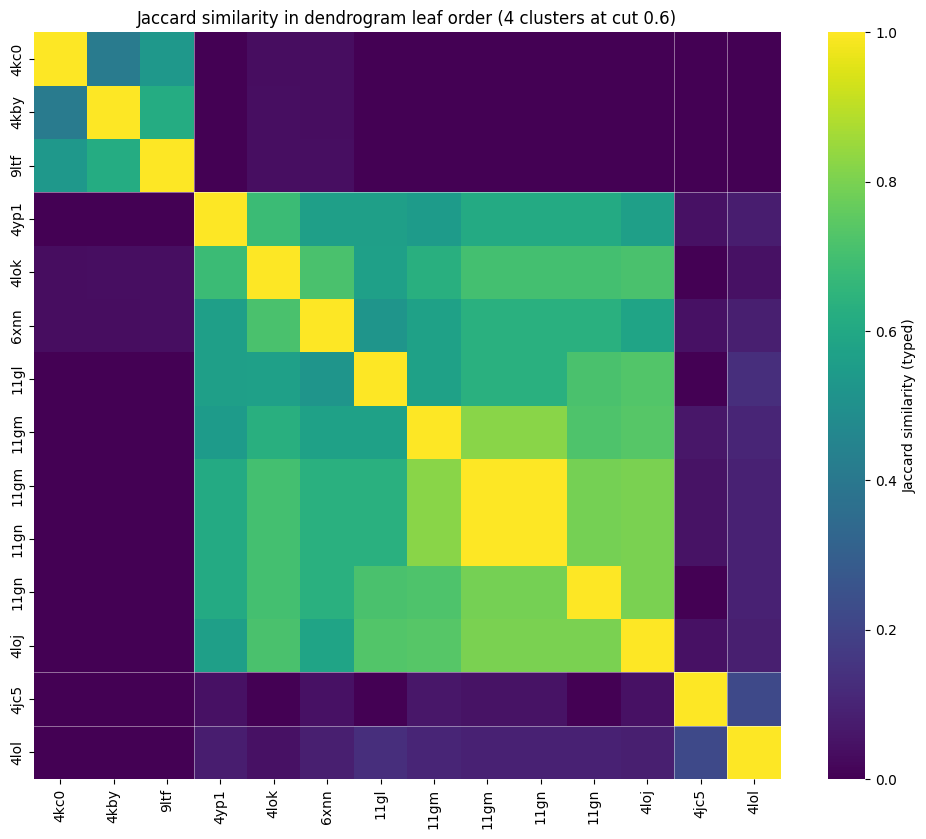

In [7]:
sim_typed = similarity.jaccard_similarity_matrix([r.uniprot_pairs for r in records])
sim_untyped = similarity.jaccard_similarity_matrix(
    [similarity.untyped(r.uniprot_pairs) for r in records]
)
cluster_result = similarity.cluster_interfaces(sim_typed, distance_cut=cfg.cluster_distance_cut)
plots.similarity_heatmap(sim_typed, records, cluster_result, cfg.cluster_distance_cut)

Maximum absolute difference between typed and untyped Jaccard: 0.036


,cut,n_clusters,largest_5_sizes,n_singletons
0,0.30,9,"[5, 2, 1, 1, 1]",7
1,0.40,6,"[8, 2, 1, 1, 1]",4
2,0.50,5,"[9, 2, 1, 1, 1]",3
3,0.55,4,"[9, 3, 1, 1]",2
4,0.60,4,"[9, 3, 1, 1]",2
5,0.65,4,"[9, 3, 1, 1]",2
6,0.70,4,"[9, 3, 1, 1]",2


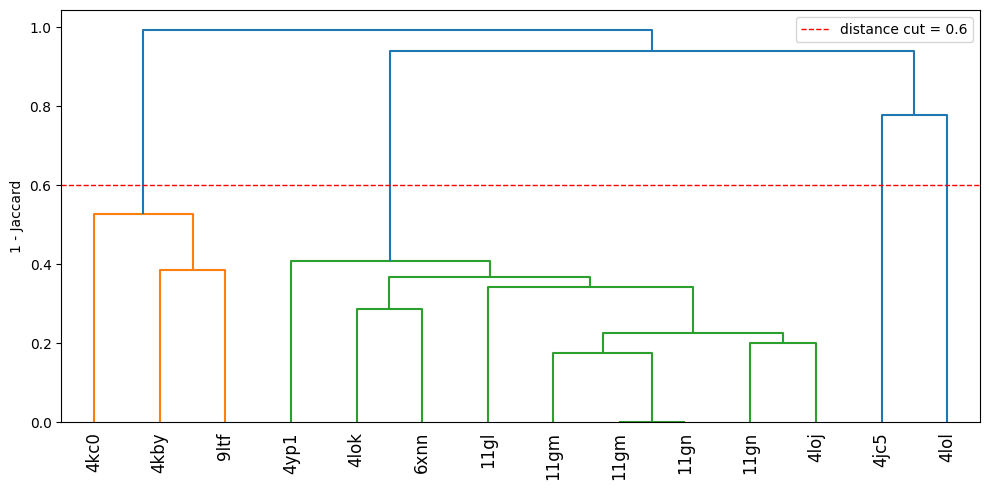

Clusters at distance cut 0.6: 4


In [8]:
print(similarity.describe_typed_untyped_divergence(sim_typed, sim_untyped))
display(similarity.sweep_cluster_cuts(cluster_result.linkage))
plots.cluster_dendrogram(cluster_result, records, cfg.cluster_distance_cut)

## Phase 4. Annotation overlap

Mutations, modifications and ligand-contact residues joined onto interface residues.

**Guidance**
- Expect only annotations at the interface; those elsewhere in the protein are discarded here.
- Add `"Conflict"` to `mutation_type_filter` if you need natural sequence variants; the default keeps engineered mutations only.
- Remove a component from `ligand_blocklist` to keep it, for example a catalytic metal.

In [9]:
overlap = annotations.overlap_annotations(
    all_records,
    mutations_response=mutations_response,
    modifications_response=modifications_response,
    ligand_contacts_by_pdb=ligand_contacts_by_pdb,
    mutation_type_filter=cfg.mutation_type_filter,
)
print(f"Mutation overlaps at interfaces: {len(overlap.mutations)}")
print(f"Modification overlaps at interfaces: {len(overlap.modifications)}")
print(f"Ligand contact overlaps at interfaces: {len(overlap.ligands)}")

Mutation overlaps at interfaces: 0
Modification overlaps at interfaces: 0
Ligand contact overlaps at interfaces: 51


In [10]:
overlap.mutations.head(20) if not overlap.mutations.empty else "No engineered mutations at any interface."

'No engineered mutations at any interface.'

In [11]:
overlap.ligands.head(20) if not overlap.ligands.empty else "No ligand contacts at any interface after filtering."

,pdb_id,assembly_id,interface_id,auth_asym_id,auth_seq_id,ins_code,unp_acc,unp_seq_id,role,ligand_chem_comp_id,ligand_chain_id,ligand_author_residue_number,contact_type
0,11gl,1,1,B,231,None,Q3TBT3,231,2,ZNT,A,401,hbond
1,11gl,1,1,A,237,None,Q3TBT3,237,1,ZNT,A,401,polar
2,11gl,1,1,A,237,None,Q3TBT3,237,1,ZNT,A,401,DONORPI
3,11gl,1,1,A,237,None,Q3TBT3,237,1,ZNT,A,401,hbond
4,11gl,1,1,A,237,None,Q3TBT3,237,1,ZNT,A,401,vdw_clash
5,11gl,1,1,B,262,None,Q3TBT3,262,2,ZNT,A,401,weak_hbond
6,11gl,1,1,A,237,None,Q3TBT3,237,1,ZNT,A,401,CATIONPI
7,11gl,1,1,B,262,None,Q3TBT3,262,2,ZNT,A,401,weak_polar
8,11gl,1,1,A,237,None,Q3TBT3,237,1,ZNT,A,401,vdw
9,4kby,1,1,A,237,None,Q3TBT3,237,1,C2E,A,401,polar


## Phase 5. Summarisation

One row per interface in the structure table. The cluster report gives each cluster's size, method, resolution, size and area distributions, core contacts, and the contacts and annotations found in it with their counts in the rest of the dataset.

**Guidance**
- Read these columns as counts. They carry no significance test, and none should be inferred from them.
- Read the entry count, not just the interface count. `2/2 interfaces = 100%, 1/1 entries` is one structure, not two.
- Compare the in-cluster and rest-of-dataset counts yourself. A contact in 100 percent of a cluster and 96 percent of everything else is not telling you anything about the cluster.
- Use the contacts to see **how** two clusters differ, and the method, resolution and annotation columns to judge **why**. Interfaces are grouped by contact similarity, so a distinct contact profile is guaranteed; whether it reflects binding or data quality is a separate question.
- No enrichment score is given for contacts, since a score computed on the contacts that produced the grouping would only restate the grouping.
- Act on the resolution warning when it fires. Contacts missing from a low-resolution cluster may simply be unresolved.

In [12]:
outputs.build_structure_table(
    records, cluster_result, overlap, partner_map,
    assembly_metadata=assembly_metadata,
)

,pdb_id,assembly_id,interface_id,partner_1,partner_2,experimental_method,resolution,interface_area,solvation_energy,stabilisation_energy,...,n_salt_bridges,n_covalent_bonds,n_disulfide_bonds,n_engineered_mutations_at_interface,n_modifications_at_interface,n_distinct_ligands_at_interface,n_ligand_contact_residues_at_interface,cluster_id,n_residues_dropped_no_uniprot,fetch_date
0,11gl,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,1.98,1979.99,-20.71,-29.89,...,2,0,0,0,0,1,3,2,0,2026-09-23
1,11gm,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,1.84,1750.35,-17.29,-24.70,...,8,0,0,0,0,0,0,2,0,2026-09-23
2,11gm,2,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,1.84,1790.99,-19.47,-26.73,...,4,0,0,0,0,0,0,2,0,2026-09-23
3,11gn,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,1.29,2059.55,-17.86,-27.41,...,3,0,0,0,0,0,0,2,0,2026-09-23
4,11gn,2,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,1.29,2108.39,-19.45,-28.93,...,4,0,0,0,0,0,0,2,0,2026-09-23
5,4jc5,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,2.75,1548.35,-16.97,-19.49,...,2,0,0,0,0,0,0,3,0,2026-09-23
6,4kby,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,2.36,1206.10,-14.17,-20.40,...,6,0,0,0,0,1,4,1,0,2026-09-23
7,4kc0,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,2.20,1282.27,-12.86,-20.12,...,4,0,0,0,0,0,0,1,0,2026-09-23
8,4loj,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,1.77,1925.38,-22.23,-31.26,...,4,0,0,0,0,0,0,2,0,2026-09-23
9,4lok,1,1,Sting1 (role 1),Sting1 (role 2),X-ray diffraction,2.07,1839.37,-19.23,-27.08,...,2,0,0,0,0,1,1,2,0,2026-09-23


In [13]:
print(outputs.describe_conservation(records, cfg.conservation_threshold))

Conserved residues at threshold 0.8: 0
Conserved interaction pairs at threshold 0.8: 0
  No residue reaches the 0.8 cutoff across 14 interfaces. The most frequent occurs in 10/14 (71%), so setting conservation_threshold to 0.71 or lower would return results.


In [14]:
report = outputs.cluster_interpretation_report(
    records, cluster_result, overlap,
    assembly_metadata=assembly_metadata,
    partner_map=partner_map,
    conservation_threshold=cfg.conservation_threshold,
)
for note in report["notes"]:
    print(note, end="\n\n")
report

Interface interaction state 2 (9 interfaces): ligands at the interface: 1YD (1/9 interfaces = 11%, 1/7 entries; rest 0/5 = 0%), 2BA (1/9 interfaces = 11%, 1/7 entries; rest 0/5 = 0%), V67 (1/9 interfaces = 11%, 1/7 entries; rest 0/5 = 0%), ZNT (1/9 interfaces = 11%, 1/7 entries; rest 0/5 = 0%) (4/9 carry an at-interface ligand contact). [methods: X-ray diffraction (9); resolution: 1.29–2.65 Å (median 1.84, n=9)]
  Residue pair count: 14–20, median 17
  Interaction count: 14–20, median 17
  Interface area: 1745–2108 Å², median 1860
  Contact density: median 0.0091 interactions/Å²
  Core contacts (>= conservation_threshold of members): Sting1:D209-Sting1:A232 hydrogen_bond (9/9, 100.0%); Sting1:D209-Sting1:G233 hydrogen_bond (9/9, 100.0%); Sting1:R231-Sting1:D209 salt_bridge (9/9, 100.0%); Sting1:A232-Sting1:D209 hydrogen_bond (9/9, 100.0%); Sting1:A232-Sting1:Y260 hydrogen_bond (9/9, 100.0%); Sting1:G233-Sting1:D209 hydrogen_bond (9/9, 100.0%); Sting1:G233-Sting1:Y244 hydrogen_bond (9/9

,cluster_id,cluster_size,member_pdb_ids,experimental_methods,resolution_range,interface_area_range,residue_pair_count_min,residue_pair_count_median,residue_pair_count_mean,residue_pair_count_max,...,cluster_ligands,cluster_contacts,cluster_contacts_shown,cluster_contacts_total,interfaces_with_any_mutation,interfaces_with_any_modification,interfaces_with_any_ligand,has_annotations,qc_warnings,notes
0,2,9,"11gl,11gm,11gn,4loj,4lok,4yp1,6xnn",X-ray diffraction (9),"1.29–2.65 Å (median 1.84, n=9)","1745–2108 Å² (median 1860, n=9)",14.0,17.0,17.555556,20.0,...,"1YD (1/9 interfaces = 11%, 1/7 entries; rest 0...",Sting1:D209-Sting1:A232 hydrogen_bond (9/9 int...,10,34,0,0,4,True,,Interface interaction state 2 (9 interfaces): ...
1,1,3,"4kby,4kc0,9ltf",X-ray diffraction (3),"1.92–2.36 Å (median 2.20, n=3)","1206–1282 Å² (median 1246, n=3)",10.0,11.0,11.333333,13.0,...,"A1ELY (1/3 interfaces = 33%, 1/3 entries; rest...",Sting1:H156-Sting1:D273 salt_bridge (3/3 inter...,10,18,0,0,2,True,,Interface interaction state 1 (3 interfaces): ...
2,3,1,4jc5,X-ray diffraction (1),"2.75–2.75 Å (median 2.75, n=1)","1548–1548 Å² (median 1548, n=1)",4.0,4.0,4.000000,4.0,...,,Sting1:K235-Sting1:N210 hydrogen_bond (1/1 int...,4,4,0,0,0,False,singleton cluster; interpret cautiously; spars...,Interface interaction state 3 (1 interfaces): ...
3,4,1,4lol,X-ray diffraction (1),"2.43–2.43 Å (median 2.43, n=1)","1487–1487 Å² (median 1487, n=1)",7.0,7.0,7.000000,7.0,...,"1YE (1/1 interfaces = 100%, 1/1 entries; rest ...",Sting1:S161-Sting1:S161 hydrogen_bond (1/1 int...,7,7,0,0,1,True,singleton cluster; interpret cautiously,Interface interaction state 4 (1 interfaces): ...


## Phase 5a. Key residue pairs

Residue-pair composition of the whole dataset or of one state. Table ranks pairs by interfaces containing them; heatmap shows partner 1 against partner 2 residues.

**Guidance**
- Check the entry counts in Phase 5 before trusting a high fraction here. Fractions are over interfaces, so a state drawn from few depositions can show 100 percent on very little evidence.

Top 15 residue pairs (all 14 interfaces); widgets disabled, showing the whole dataset. Set PDBE_INTERFACES_STATIC=0 for the interactive view.


,contact,n_interfaces,fraction
0,Sting1:S242 – Sting1:K235,10,0.714
1,Sting1:A232 – Sting1:D209,9,0.643
2,Sting1:A232 – Sting1:Y260,9,0.643
3,Sting1:D209 – Sting1:A232,9,0.643
4,Sting1:D209 – Sting1:G233,9,0.643
5,Sting1:G233 – Sting1:D209,9,0.643
6,Sting1:G233 – Sting1:Y244,9,0.643
7,Sting1:Q265 – Sting1:R231,9,0.643
8,Sting1:R231 – Sting1:D209,9,0.643
9,Sting1:Y244 – Sting1:G233,9,0.643


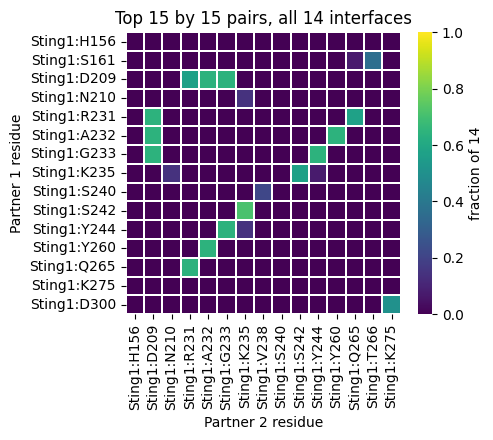

In [15]:
explorer.residue_pair_explorer(records, cluster_result, partner_map)

## Phase 5b. Interface rewiring between interaction states

Contacts shared, gained or lost between two states. Labels: **shared core** at 80 percent or more of members in both, **higher in A** or **higher in B** when fractions differ by 0.5 or more, **rare** otherwise. The two largest non-singleton states are compared by default; pass `cluster_a` and `cluster_b` to `outputs.compare_cluster_contacts` for another pair.

**Guidance**
- Compare states of similar size. In a two-interface state a single structure moves the fraction by half, which is enough to flip a label.
- Treat the labels as conventions for reading the table, not as test outcomes.

In [16]:
rewiring, rewiring_note = outputs.rewiring_table(
    records, cluster_result, partner_map=partner_map, top_n=20,
)
print(rewiring_note)
rewiring

State 2 (n=9) versus state 1 (n=3), sorted by absolute fraction difference, top 20.


,contact,cluster_A_count,cluster_B_count,cluster_A_fraction,cluster_B_fraction,fraction_difference,contact_direction
0,Sting1:A232-Sting1:D209 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A
1,Sting1:A232-Sting1:Y260 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A
2,Sting1:D209-Sting1:A232 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A
3,Sting1:D209-Sting1:G233 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A
4,Sting1:D273-Sting1:H156 salt_bridge,0,3,0.000,1.0,-1.000,higher in B
5,Sting1:G233-Sting1:D209 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A
6,Sting1:G233-Sting1:Y244 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A
7,Sting1:H156-Sting1:D273 salt_bridge,0,3,0.000,1.0,-1.000,higher in B
8,Sting1:N210-Sting1:R168 hydrogen_bond,0,3,0.000,1.0,-1.000,higher in B
9,Sting1:Q265-Sting1:R231 hydrogen_bond,9,0,1.000,0.0,1.000,higher in A


## Phase 6. Visualise cluster representatives in Mol*

One representative per cluster: both chains coloured distinctly, interface residues as ball-and-stick, at-interface mutations in red. The representative is the member with the best resolution, chosen deterministically.

**Guidance**
- Use the Phase 5 distributions to judge how well the representative stands for its cluster; a single structure shows nothing of the spread.

In [17]:
visualize.visualize_clusters_grid(
    records, cluster_result, overlap=overlap,
    assembly_metadata=assembly_metadata,
    min_cluster_size=5,
    max_clusters=6,
)

**Showing 1 cluster representatives** (min_cluster_size=5, max_clusters=6). Skipped: 3 smaller clusters.

### Cluster 2 (n=9), representative `11gn` (assembly 1, interface 1, 1.29 Å)

<IPython.core.display.Javascript object>

## Phase 7. Export interface conservation JSON

Residue-level conservation and contact frequencies for downstream use. Export only. Conservation is bucketed as strong at 0.80 and above, medium from 0.50, weak from 0.20, rare below.

**Guidance**
- Record which run an export came from. The frequencies describe the structures analysed here after the Phase 1 filters, and change as new structures are deposited. The configuration is stored in the file.

In [18]:
export_data = outputs.export_interface_frequency_json(
    records, partner_map=partner_map, complex_id=complex_id,
    complex_name=details.get("name"), oligomeric_state=details.get("oligomeric_state"),
    config=cfg, typed_contacts=True, complex_details=details,
)
preview = outputs.export_preview(export_data)
print(f"Exported {len(export_data['residue_frequencies'])} residue frequencies and "
      f"{len(export_data['contact_frequencies'])} contact frequencies")
display(preview["residues"], preview["contacts"])

Exported 52 residue frequencies and 53 contact frequencies


,unp_accession,role,unp_residue_number,unp_residue_label,n_interfaces,frequency,conservation_level
0,Q3TBT3,2,235,K235,10,0.7143,medium
1,Q3TBT3,1,209,D209,10,0.7143,medium
2,Q3TBT3,1,265,Q265,10,0.7143,medium
3,Q3TBT3,1,244,Y244,10,0.7143,medium
4,Q3TBT3,1,242,S242,10,0.7143,medium
5,Q3TBT3,2,209,D209,10,0.7143,medium
6,Q3TBT3,1,235,K235,10,0.7143,medium
7,Q3TBT3,2,233,G233,9,0.6429,medium
8,Q3TBT3,2,232,A232,9,0.6429,medium
9,Q3TBT3,1,260,Y260,9,0.6429,medium


,partner_1,partner_2,bond_type,n_interfaces,frequency
0,S242,K235,hydrogen_bond,10,0.7143
1,D209,G233,hydrogen_bond,9,0.6429
2,Y244,G233,hydrogen_bond,9,0.6429
3,R231,D209,salt_bridge,9,0.6429
4,G233,D209,hydrogen_bond,9,0.6429
5,G233,Y244,hydrogen_bond,9,0.6429
6,A232,Y260,hydrogen_bond,9,0.6429
7,D209,A232,hydrogen_bond,9,0.6429
8,A232,D209,hydrogen_bond,9,0.6429
9,Y260,A232,hydrogen_bond,9,0.6429


## Licence

```
Copyright 2026 EMBL - European Bioinformatics Institute
Author: Sri Devan Appasamy

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```